# EDA Demo Notebook

This notebook demonstrates exploratory data analysis on `examples/data/sample.csv`.

It is intentionally simple — the goal is to give the Copilot skills in this repo a realistic notebook to work with.

**Skills that work well with this notebook:**
- `explore-dataset` — asks Copilot to summarise the data
- `explain-notebook` — asks Copilot to explain what this notebook does

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 1. Load and inspect

In [2]:
df = pd.read_csv('../../examples/data/sample.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (25, 6)


,age,income,education_years,hours_per_week,occupation,income_bracket
0,25,32000,13,40,Tech,<=50K
1,38,85000,16,50,Finance,>50K
2,45,52000,12,38,Retail,<=50K
3,28,47000,14,40,Tech,<=50K
4,55,120000,18,60,Executive,>50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              25 non-null     int64 
 1   income           25 non-null     int64 
 2   education_years  25 non-null     int64 
 3   hours_per_week   25 non-null     int64 
 4   occupation       25 non-null     object
 5   income_bracket   25 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.3+ KB


In [4]:
df.describe()

,age,income,education_years,hours_per_week
count,25.000000,25.000000,25.000000,25.000000
mean,37.440000,63400.000000,14.600000,44.000000
std,10.508251,27192.217024,1.825742,6.557439
min,22.000000,28000.000000,12.000000,35.000000
25%,29.000000,41000.000000,13.000000,40.000000
50%,36.000000,58000.000000,14.000000,42.000000
75%,45.000000,85000.000000,16.000000,48.000000
max,61.000000,120000.000000,18.000000,60.000000


## 2. Missing values

In [5]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values')

No missing values


## 3. Target distribution

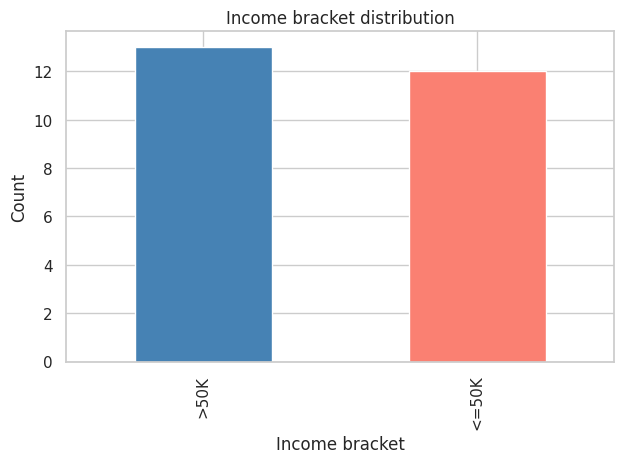

In [6]:
ax = df['income_bracket'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
ax.set_title('Income bracket distribution')
ax.set_xlabel('Income bracket')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Numeric feature distributions

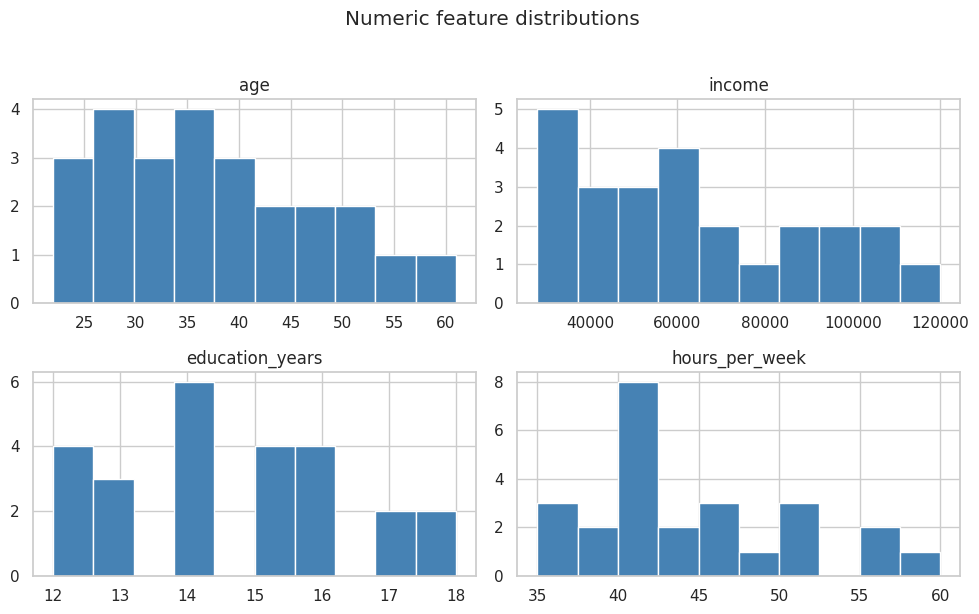

In [7]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
df[numeric_cols].hist(bins=10, figsize=(10, 6), color='steelblue', edgecolor='white')
plt.suptitle('Numeric feature distributions', y=1.02)
plt.tight_layout()
plt.show()

## 5. Correlation heatmap

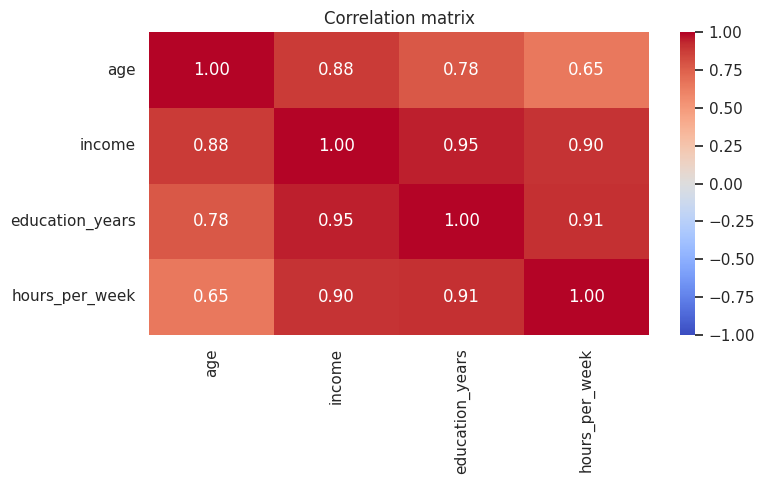

In [8]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()